# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Análisis de Series de Tiempo**

In [1]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Descomposición y predicción paso a paso

---

## Dataset: Ventas de antiabéticos en Australia (`a10`)

El **"primer elemento"** es la Tendencia ($T$). Para que una computadora la calcule, necesitamos transformar fechas en números continuos.

$$Ventas = \beta_0 + \beta_1 \cdot (\text{Trend})$$

Siendo $X$ la variable independiente (Trend) e $Y$ las ventas (variable dependiente).

In [2]:
# Cargamos el dataset a10 de statsmodels
a10 = sm.datasets.get_rdataset("a10", "fpp2").data
a10.head()

,time,value
0,1991.500000,3.526591
1,1991.583333,3.180891
2,1991.666667,3.252221
3,1991.750000,3.611003
4,1991.833333,3.565869


In [3]:
# Convertimos la columna 'time' (decimal) a fecha año-mes
years  = a10['time'].astype(int)
months = ((a10['time'] - years) * 12 + 1).round().astype(int)

# Preparamos el campo fecha y lo volvemos índice
a10['date'] = pd.to_datetime(dict(year=years, month=months, day=1))
a10.set_index('date', inplace=True)

df = a10.copy()

In [4]:
df.head()

,time,value
date,,
1991-07-01,1991.500000,3.526591
1991-08-01,1991.583333,3.180891
1991-09-01,1991.666667,3.252221
1991-10-01,1991.750000,3.611003
1991-11-01,1991.833333,3.565869


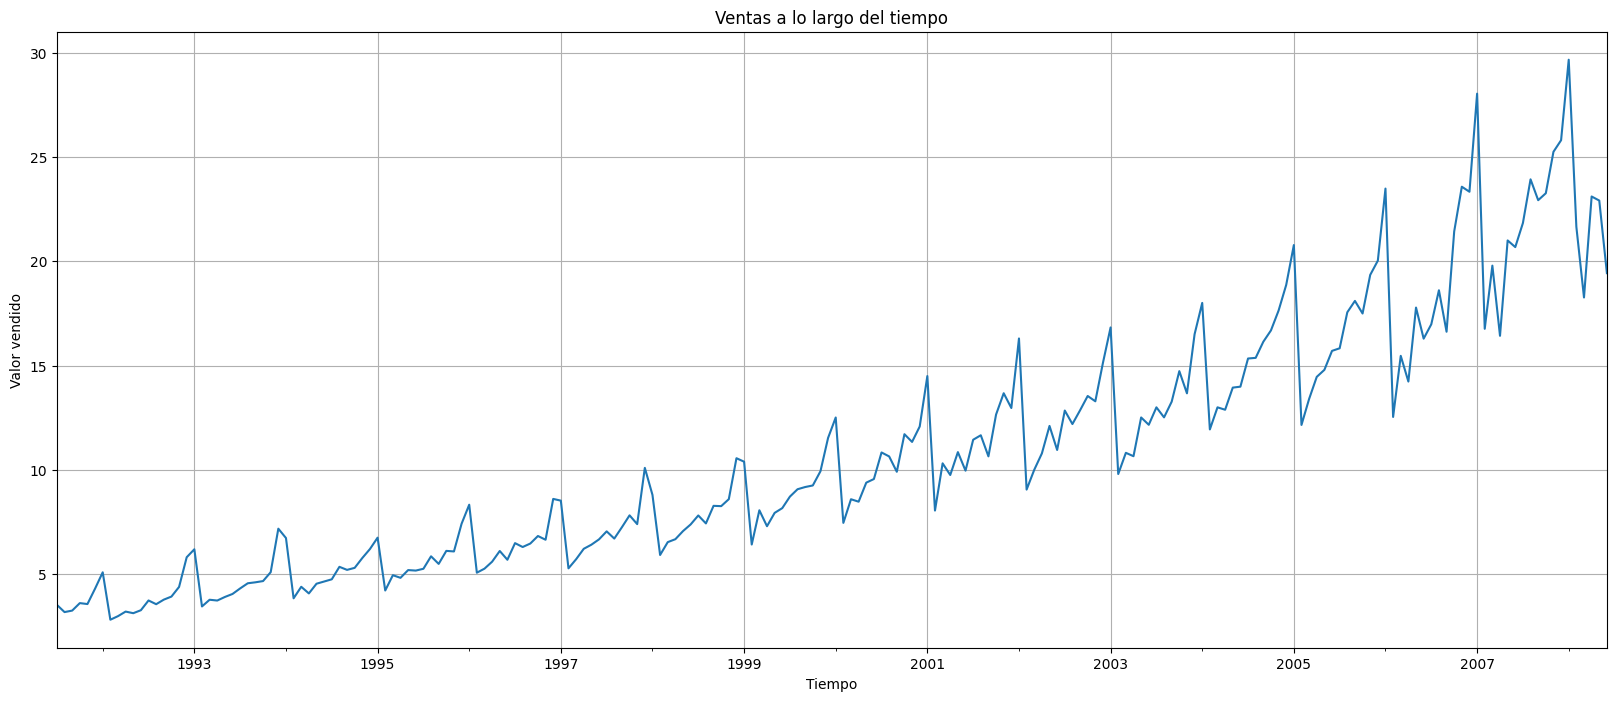

In [5]:
# Gráfico de línea básico
df['value'].plot(figsize=(20, 8), title='Ventas a lo largo del tiempo')
plt.ylabel('Valor vendido')
plt.xlabel('Tiempo')
plt.grid(True)
plt.show()

## Paso 1 — Tendencia

Creamos la variable **Trend**: simplemente el número de fila. Esto le dice al modelo "cuánto tiempo ha pasado".

In [6]:
# Creamos la variable de Tendencia (Trend)
df['trend'] = range(len(df))
df.head()

,time,value,trend
date,,,
1991-07-01,1991.500000,3.526591,0
1991-08-01,1991.583333,3.180891,1
1991-09-01,1991.666667,3.252221,2
1991-10-01,1991.750000,3.611003,3
1991-11-01,1991.833333,3.565869,4


El concepto de **Residuos** (lo que falta explicar):

$$Y = T + C + S + I$$

La línea de tendencia (roja) no toca todos los puntos azules. Esa "distancia" entre el punto azul y la línea roja es lo que llamamos **Residuo**. Ese residuo contiene la Estacionalidad (los picos y valles que se repiten) y el Error Aleatorio.

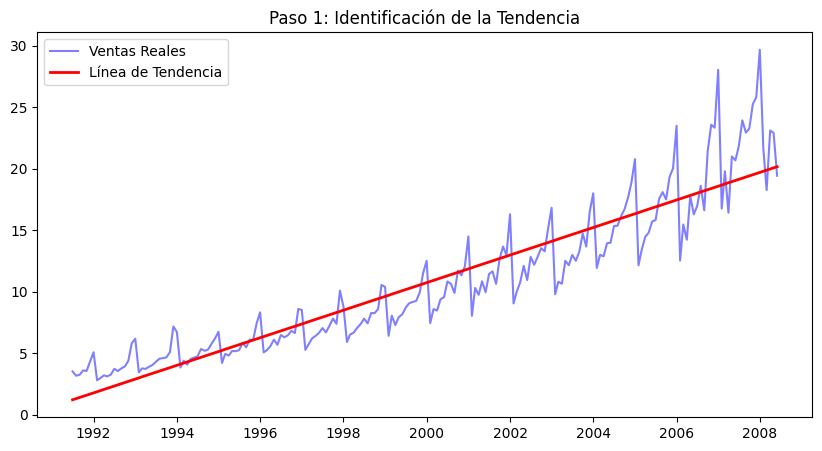

In [7]:
# Definimos las variables
X = df[['trend']]  # doble [[]] porque la función espera una matriz
y = df['value']

# Creamos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Guardamos la tendencia en el DataFrame
df['trend_line'] = modelo.predict(X)

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['value'],      label='Ventas Reales',      color='blue', alpha=0.5)
plt.plot(df.index, df['trend_line'], label='Línea de Tendencia', color='red',  linewidth=2)
plt.title('Paso 1: Identificación de la Tendencia')
plt.legend()
plt.show()

## Paso 2 — Estacionalidad

Hasta ahora la línea de tendencia asume que las ventas siempre suben al mismo ritmo. Pero hay meses donde se vende más (p. ej. diciembre) y meses donde cae. Para que el modelo se mueva con los datos, necesitamos el componente **Estacional**.

La regresión simple ahora es **múltiple**:

$$\hat{y} = \beta_0 + \beta_1(\text{trend}) + \beta_2(\text{mes}_2) + \beta_3(\text{mes}_3) + \cdots + \beta_{12}(\text{mes}_{12})$$

In [11]:
# Extraemos el mes del índice
df['month'] = df.index.month

# Creamos variables Dummies (drop_first para evitar multicolinealidad)
df_dummies = pd.get_dummies(df['month'], prefix='mes', drop_first=True)

df_dummies.head()

,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
date,,,,,,,,,,,
1991-07-01,False,False,False,False,False,True,False,False,False,False,False
1991-08-01,False,False,False,False,False,False,True,False,False,False,False
1991-09-01,False,False,False,False,False,False,False,True,False,False,False
1991-10-01,False,False,False,False,False,False,False,False,True,False,False
1991-11-01,False,False,False,False,False,False,False,False,False,True,False


In [13]:
# Unimos tendencia con los meses
X_multiple = pd.concat([df[['trend']], df_dummies], axis=1)
y = df['value']

# Entrenamos el modelo de Regresión Múltiple
modelo_completo = LinearRegression()
modelo_completo.fit(X_multiple, y)

# Predicción con tendencia Y estacionalidad
df['prediccion_estacional'] = modelo_completo.predict(X_multiple)
df['prediccion_estacional']

date
1991-07-01     0.981355
1991-08-01     1.260086
1991-09-01     1.229407
1991-10-01     2.012679
1991-11-01     2.481580
                ...    
2008-02-01    17.617492
2008-03-01    18.494311
2008-04-01    18.557798
2008-05-01    19.568355
2008-06-01    19.226937
Name: prediccion_estacional, Length: 204, dtype: float64

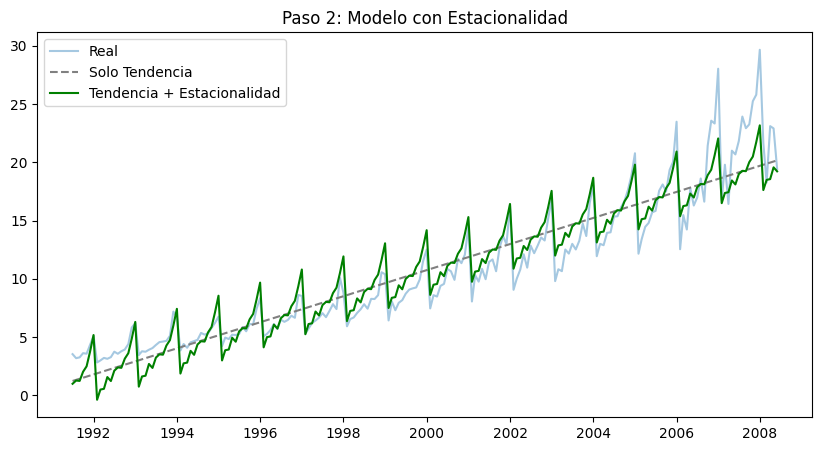

In [14]:
# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['value'],                  label='Real',                        alpha=0.4)
plt.plot(df.index, df['trend_line'],      '--',  label='Solo Tendencia',     color='gray')
plt.plot(df.index, df['prediccion_estacional'],  label='Tendencia + Estacionalidad', color='green')
plt.legend()
plt.title('Paso 2: Modelo con Estacionalidad')
plt.show()

## Paso 3 — Evaluación del modelo

Comparamos las predicciones del modelo con los datos reales mediante métricas de error.

In [15]:
y_true = df['value']
y_pred = df['prediccion_estacional']

r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("--- Evaluación del Modelo ---")
print(f"R-cuadrado (R²)                    : {r2:.4f}")
print(f"Error Absoluto Medio (MAE)         : {mae:.2f}")
print(f"Error Cuadrático Medio (MSE)       : {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

--- Evaluación del Modelo ---
R-cuadrado (R²)                    : 0.9205
Error Absoluto Medio (MAE)         : 1.30
Error Cuadrático Medio (MSE)       : 2.81
Raíz del Error Cuadrático Medio (RMSE): 1.68


## Paso 4 — Componente cíclico

**¿Dónde está el Ciclo?** En nuestro modelo actual, el ciclo está "escondido" en dos lugares:
- Una parte se la llevó la Tendencia (si el ciclo es muy largo).
- La mayor parte está en los **Residuos** (lo que el modelo no pudo explicar con la tendencia ni con los meses).

Para ver el ciclo, suavizamos el residuo con una media móvil. Esto elimina el ruido aleatorio ($I$) y deja ver la onda del ciclo ($C$).

> **Nota:** Para predecir ciclos se necesitan modelos que incorporen otras variables (p. ej. tasa de interés, inflación) o modelos avanzados como ARIMA. El ciclo es la parte "humana" de la economía; el modelo sabe que es diciembre, pero no sabe si el país está en crisis o en crecimiento.

In [16]:
# Calculamos el Residuo (C + R)
df['residuo'] = df['value'] - df['prediccion_estacional']

# Suavizamos con media móvil para aislar el ciclo
df['ciclo'] = df['residuo'].rolling(window=9).mean()

In [17]:
df['residuo'].head()

date
1991-07-01    2.545236
1991-08-01    1.920805
1991-09-01    2.022814
1991-10-01    1.598324
1991-11-01    1.084289
Name: residuo, dtype: float64

In [18]:
df['ciclo'].head()

date
1991-07-01   NaN
1991-08-01   NaN
1991-09-01   NaN
1991-10-01   NaN
1991-11-01   NaN
Name: ciclo, dtype: float64

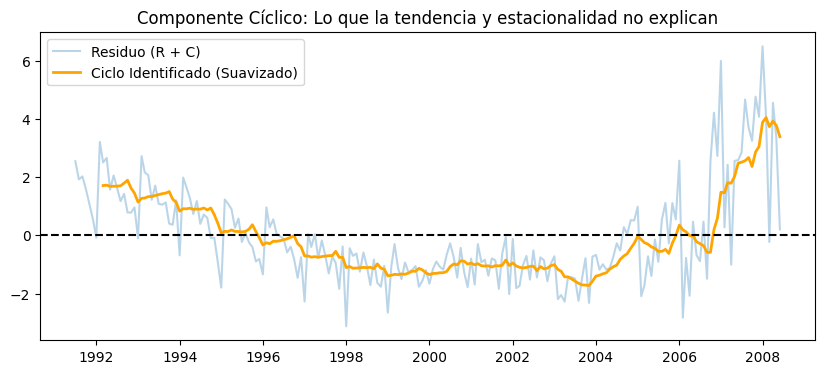

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['residuo'], label='Residuo (R + C)', alpha=0.3)
plt.plot(df.index, df['ciclo'],   label='Ciclo Identificado (Suavizado)', color='orange', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.title('Componente Cíclico: Lo que la tendencia y estacionalidad no explican')
plt.legend()
plt.show()

## Paso 5 — Pronóstico a 24 meses

In [20]:
# Definimos cuántos meses queremos predecir
meses_a_predecir = 24
ultima_fecha = df.index[-1]
ult_trend    = df['trend'].max()

# Creamos las fechas futuras
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.DateOffset(months=1),
    periods=meses_a_predecir,
    freq='ME'
)

In [21]:
# DataFrame del futuro con las variables explicativas
df_futuro = pd.DataFrame(index=fechas_futuras)
df_futuro['trend'] = range(ult_trend + 1, ult_trend + 1 + meses_a_predecir)
df_futuro['month'] = df_futuro.index.month

# Dummies del futuro (deben coincidir con las del entrenamiento)
X_futuro_dummies = pd.get_dummies(df_futuro['month'], prefix='mes', drop_first=True)

# Alineamos columnas con el modelo entrenado
X_futuro = pd.concat([df_futuro[['trend']], X_futuro_dummies], axis=1)
X_futuro = X_futuro.reindex(columns=X_multiple.columns, fill_value=0)

In [22]:
# Predicción
pronostico = modelo_completo.predict(X_futuro)
df_futuro['pronostico'] = pronostico

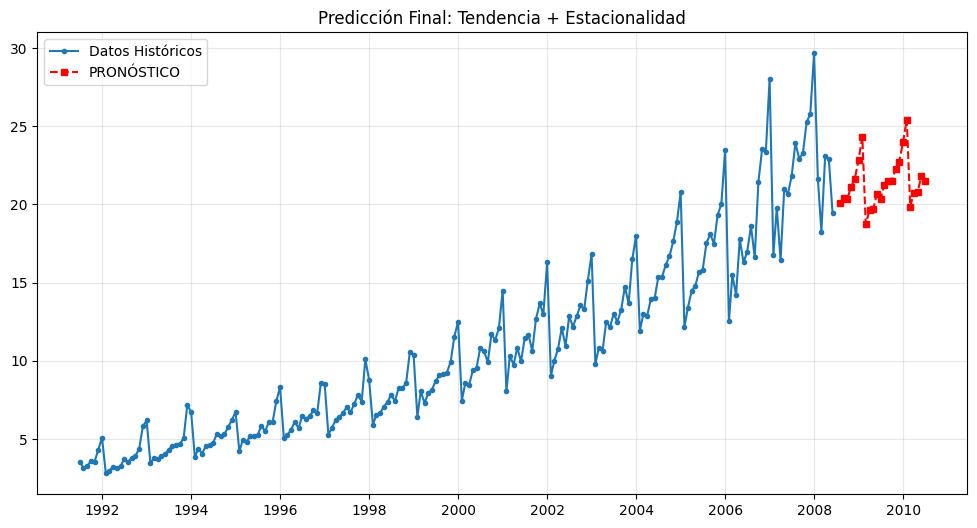

In [23]:
# Visualización Final
plt.figure(figsize=(12, 6))
plt.plot(df.index,        df['value'],            label='Datos Históricos', marker='o', markersize=3)
plt.plot(df_futuro.index, df_futuro['pronostico'], label='PRONÓSTICO',       color='red', ls='--', marker='s', markersize=4)
plt.title('Predicción Final: Tendencia + Estacionalidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

## Descomposición con `seasonal_decompose`

Para este análisis es importante ajustar el parámetro `period` según la frecuencia de los datos:

| `period` | Frecuencia de datos |
|---|---|
| 12 | mensual (ciclo anual) |
| 7  | diario (ciclo semanal) |
| 4  | trimestral |
| 24 | horario (ciclo diario) |

También es preciso definir si el modelo es:

- **Aditivo** (amplitud de la estacionalidad constante): $Y = T + E + R$  
  Usar cuando las oscilaciones tienen tamaño similar en toda la serie.

- **Multiplicativo** (estacionalidad crece con el nivel): $Y = T \times E \times R$  
  Usar cuando la serie crece y los picos también crecen proporcionalmente.

Ese análisis se debe hacer observando la serie de tiempo.

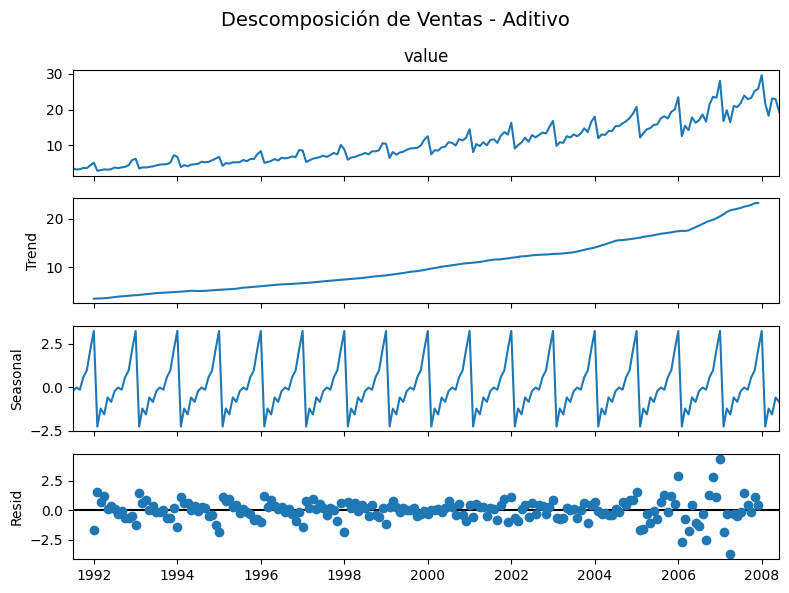

In [24]:
# Descomposición ADITIVA
resultado_a = seasonal_decompose(df['value'], model='additive', period=12)

fig = resultado_a.plot()
fig.set_size_inches(8, 6)
plt.suptitle('Descomposición de Ventas - Aditivo', fontsize=14)
plt.tight_layout()
plt.show()

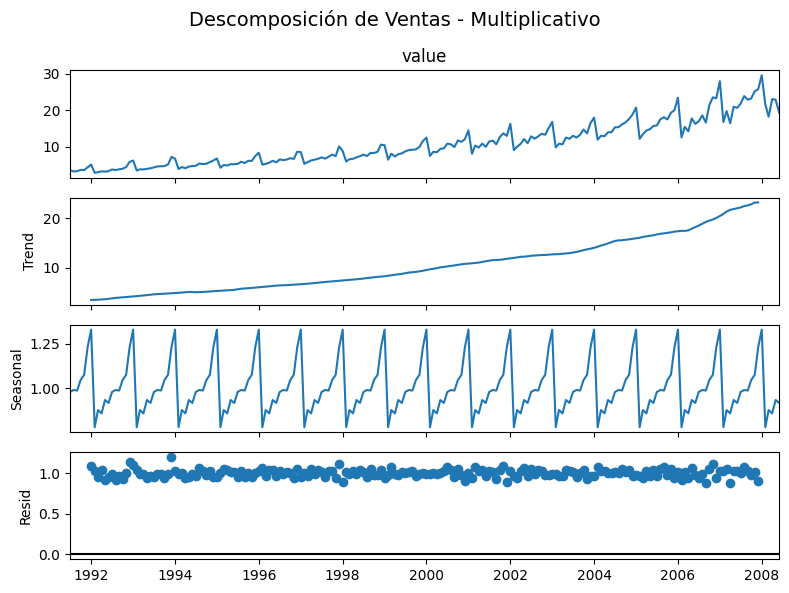

In [25]:
# Descomposición MULTIPLICATIVA
resultado_m = seasonal_decompose(df['value'], model='multiplicative', period=12)

fig = resultado_m.plot()
fig.set_size_inches(8, 6)
plt.suptitle('Descomposición de Ventas - Multiplicativo', fontsize=14)
plt.tight_layout()
plt.show()

### Función de Autocorrelación (ACF) de los residuos

El mejor modelo es el que deja **residuos sin autocorrelación** (ruido blanco).

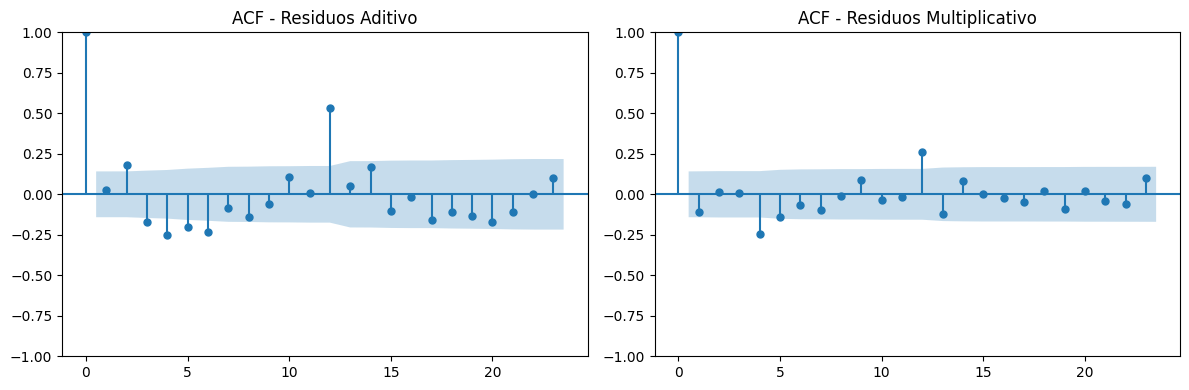

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(resultado_a.resid.dropna(), ax=axes[0])
axes[0].set_title("ACF - Residuos Aditivo")

plot_acf(resultado_m.resid.dropna(), ax=axes[1])
axes[1].set_title("ACF - Residuos Multiplicativo")

plt.tight_layout()
plt.show()

### Residuos en el tiempo

En la descomposición clásica, el ciclo **no está separado explícitamente**: queda mezclado principalmente en la tendencia (promedio móvil de baja frecuencia) y en parte en el residuo cuando el ciclo no coincide con la ventana del promedio móvil.

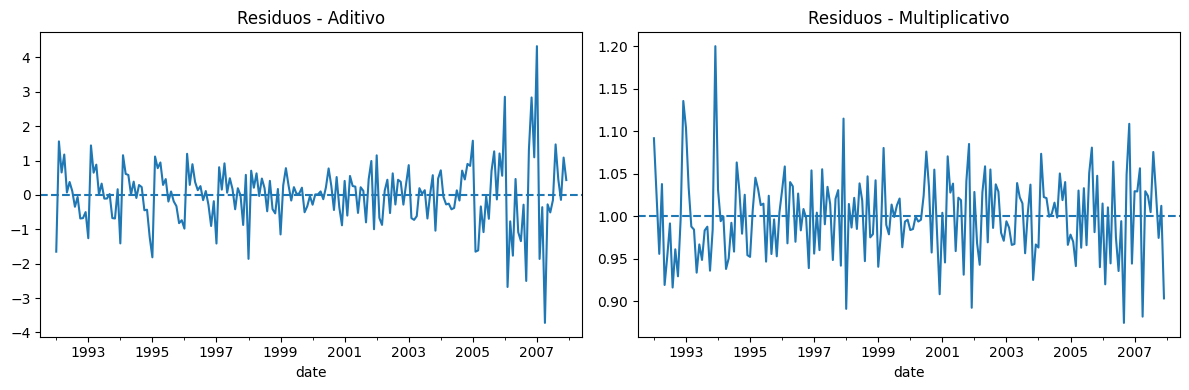

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

resultado_a.resid.plot(ax=axes[0], title="Residuos - Aditivo")
axes[0].axhline(0, linestyle="--")

resultado_m.resid.plot(ax=axes[1], title="Residuos - Multiplicativo")
axes[1].axhline(1, linestyle="--")

plt.tight_layout()
plt.show()

---

## Otro ejemplo: Desempleo en EE.UU. (`macrodata`)

Datos macroeconómicos trimestrales de EE.UU. Se pueden observar **ciclos de entre 4 y 5 años** de longitud.

In [28]:
# Dataset de Python disponible en statsmodels
usa = sm.datasets.macrodata.load_pandas().data

usa['date'] = pd.to_datetime(
    usa['year'].astype(int).astype(str) + 'Q' + usa['quarter'].astype(int).astype(str)
)
usa.set_index('date', inplace=True)

C:\Users\Alexander\AppData\Local\Temp\ipykernel_27504\3748047532.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usa['date'] = pd.to_datetime(


In [29]:
usa.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
date,,,,,,,,,,,,,,
1959-01-01,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-04-01,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-07-01,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-10-01,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-01-01,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


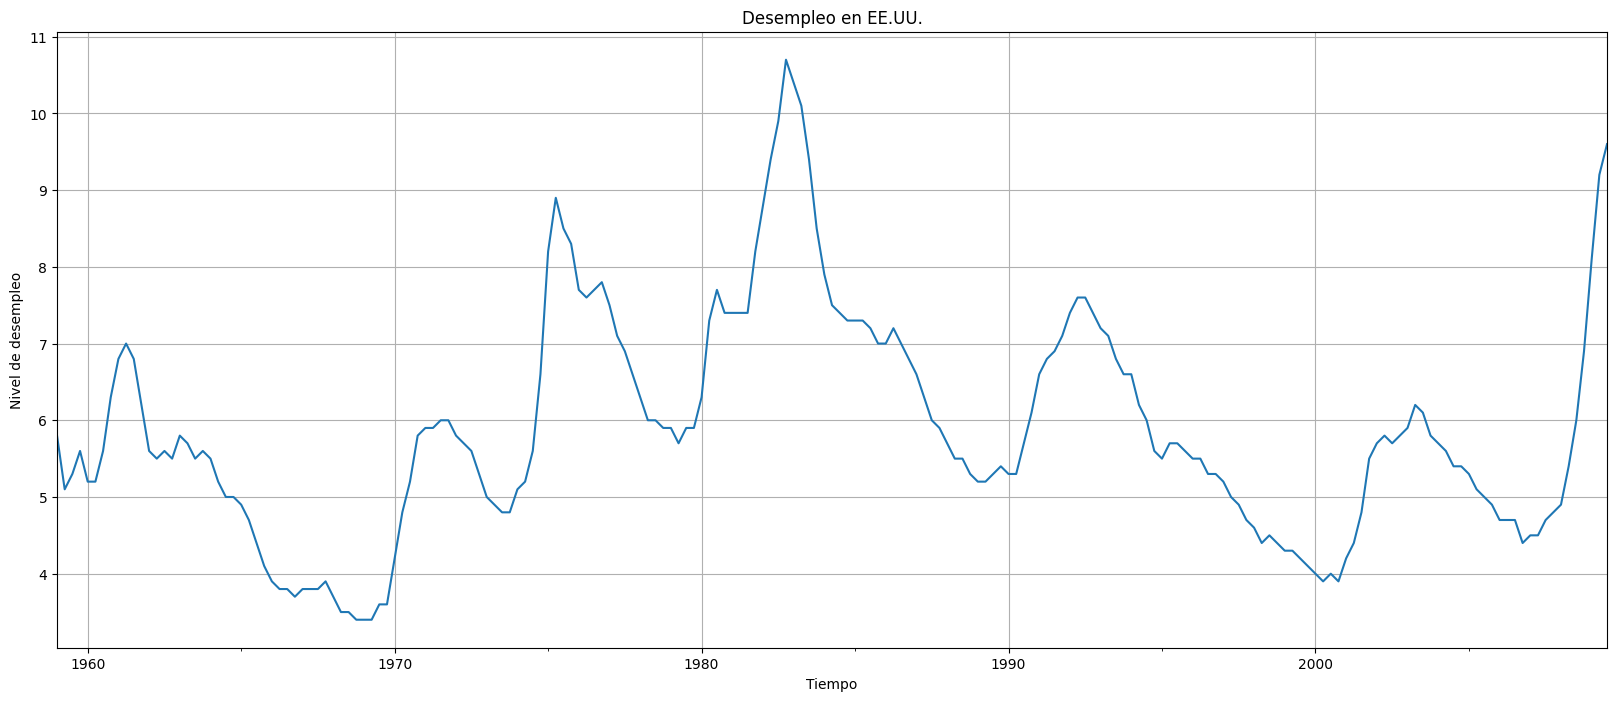

In [30]:
usa['unemp'].plot(figsize=(20, 8), title='Desempleo en EE.UU.')
plt.ylabel('Nivel de desempleo')
plt.xlabel('Tiempo')
plt.grid(True)
plt.show()

### Efecto del parámetro `period`

Hay una **compensación**: las ventanas cortas generan tendencias inestables (sobreajuste), mientras que las ventanas largas pueden dejar estructura no capturada en los residuos.

#### `period=4` (ciclo anual)

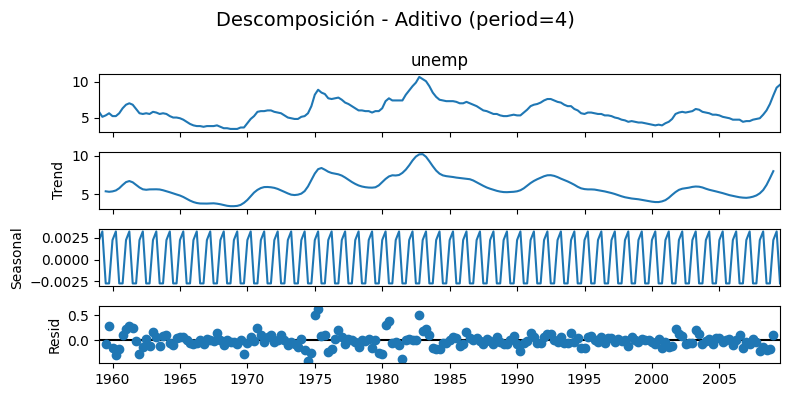

In [31]:
resultado_a = seasonal_decompose(usa['unemp'], model='additive', period=4)

fig = resultado_a.plot()
fig.set_size_inches(8, 4)
plt.suptitle('Descomposición - Aditivo (period=4)', fontsize=14)
plt.tight_layout()
plt.show()

#### `period=12` (3 años)

Se está **sobreajustando la tendencia**: el promedio móvil es muy corto → deja pasar estacionalidad/ciclo como si fuera tendencia.

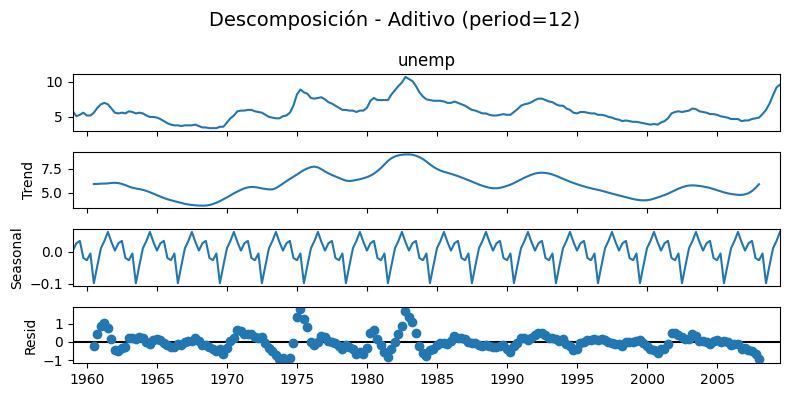

In [32]:
resultado_a = seasonal_decompose(usa['unemp'], model='additive', period=12)

fig = resultado_a.plot()
fig.set_size_inches(8, 4)
plt.suptitle('Descomposición - Aditivo (period=12)', fontsize=14)
plt.tight_layout()
plt.show()

#### `period=20` (5 años)

La tendencia es más suave y predecible a largo plazo, pero absorbe parte del ciclo económico (no es recta).
La estacionalidad es más razonable que antes: patrón estable, amplitud consistente.
Los residuos presentan cierta estructura que el modelo no puede explicar.

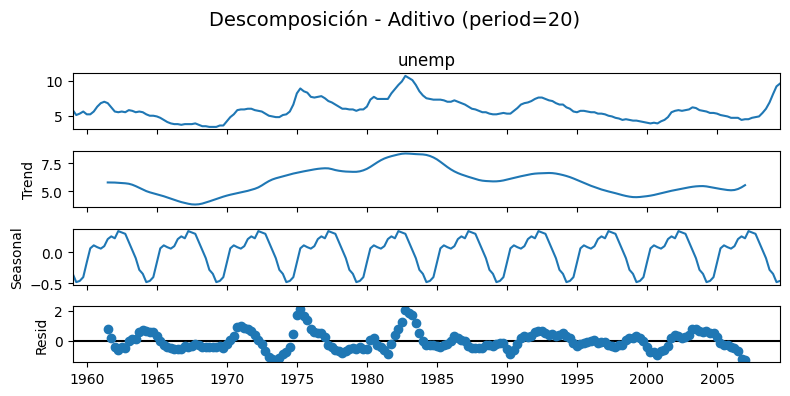

In [33]:
resultado_a = seasonal_decompose(usa['unemp'], model='additive', period=20)

fig = resultado_a.plot()
fig.set_size_inches(8, 4)
plt.suptitle('Descomposición - Aditivo (period=20)', fontsize=14)
plt.tight_layout()
plt.show()

#### `period=40` (10 años)

La elección del número de períodos implica un compromiso: los valores bajos generan tendencias inestables, mientras que los valores altos pueden dejar dependencia temporal en los residuos, evidenciando que el análisis clásico no captura toda la dinámica de la serie.

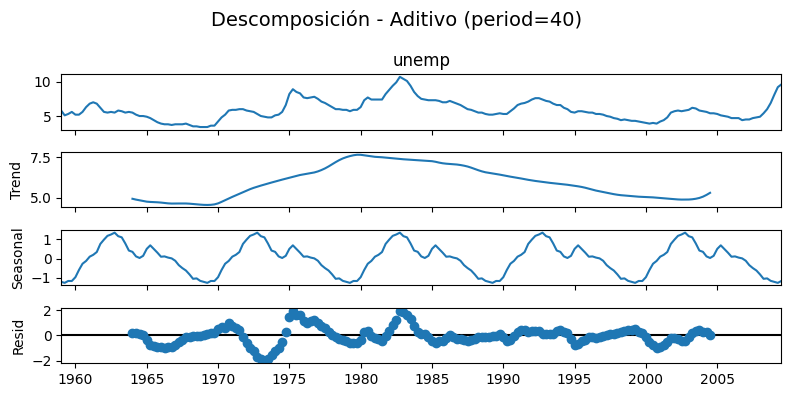

In [34]:
resultado_a = seasonal_decompose(usa['unemp'], model='additive', period=40)

fig = resultado_a.plot()
fig.set_size_inches(8, 4)
plt.suptitle('Descomposición - Aditivo (period=40)', fontsize=14)
plt.tight_layout()
plt.show()